---
## Q1 – Real Estate House Price Prediction (Linear Regression)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── 1. Synthetic Dataset ──────────────────────────────────────────────────────
np.random.seed(42)
n = 200
neighborhoods = ['Downtown', 'Suburbs', 'Rural', 'Midtown']

df_house = pd.DataFrame({
    'sqft':         np.random.randint(600, 4000, n),
    'bedrooms':     np.random.randint(1, 6, n),
    'bathrooms':    np.random.randint(1, 4, n),
    'age':          np.random.randint(0, 50, n),
    'neighborhood': np.random.choice(neighborhoods, n),
})
# Introduce a few missing values
df_house.loc[np.random.choice(n, 10, replace=False), 'sqft'] = np.nan
df_house.loc[np.random.choice(n, 5,  replace=False), 'age']  = np.nan

# Price formula with neighborhood effect
neigh_bonus = {'Downtown': 50000, 'Midtown': 30000, 'Suburbs': 10000, 'Rural': 0}
df_house['price'] = (
    df_house['sqft'].fillna(df_house['sqft'].median()) * 150
    + df_house['bedrooms']  * 8000
    + df_house['bathrooms'] * 5000
    - df_house['age'].fillna(df_house['age'].median()) * 500
    + df_house['neighborhood'].map(neigh_bonus)
    + np.random.normal(0, 15000, n)
)

print("── Dataset head ──")
print(df_house.head())
print("\n── Missing values ──")
print(df_house.isnull().sum())

── Dataset head ──
     sqft  bedrooms  bathrooms   age neighborhood          price
0  3774.0         1          2  34.0      Midtown  627183.610685
1  1460.0         1          2  22.0        Rural  236763.873697
2  1894.0         1          1  28.0        Rural  276062.784197
3  1730.0         3          2  42.0        Rural  280404.061189
4  1695.0         1          2  10.0        Rural  291558.001677

── Missing values ──
sqft            10
bedrooms         0
bathrooms        0
age              5
neighborhood     0
price            0
dtype: int64


In [3]:
# ── 2. Clean & Encode ─────────────────────────────────────────────────────────
df_house['sqft'].fillna(df_house['sqft'].median(), inplace=True)
df_house['age'].fillna(df_house['age'].median(),   inplace=True)

le = LabelEncoder()
df_house['neighborhood_enc'] = le.fit_transform(df_house['neighborhood'])

print("Neighborhood encoding:", dict(zip(le.classes_, le.transform(le.classes_))))
print("\nMissing values after cleaning:")
print(df_house.isnull().sum())

Neighborhood encoding: {'Downtown': np.int64(0), 'Midtown': np.int64(1), 'Rural': np.int64(2), 'Suburbs': np.int64(3)}

Missing values after cleaning:
sqft                0
bedrooms            0
bathrooms           0
age                 0
neighborhood        0
price               0
neighborhood_enc    0
dtype: int64


/tmp/ipykernel_17754/4255525429.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_house['sqft'].fillna(df_house['sqft'].median(), inplace=True)
/tmp/ipykernel_17754/4255525429.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

── Correlation with price ──
sqft                0.981200
age                 0.116175
bedrooms            0.033658
bathrooms          -0.008167
neighborhood_enc   -0.149377
Name: price, dtype: float64


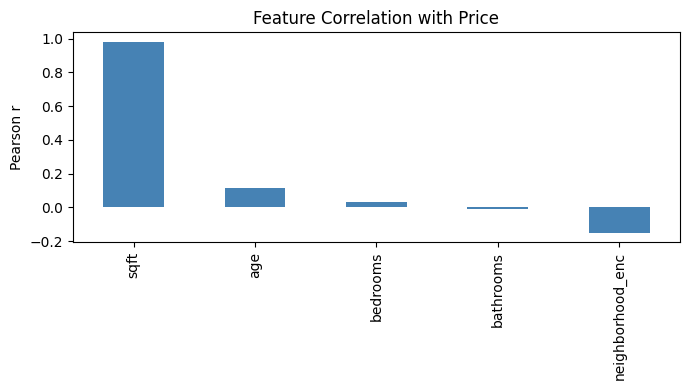

In [4]:
# ── 3. Feature Importance (correlation) ───────────────────────────────────────
features = ['sqft', 'bedrooms', 'bathrooms', 'age', 'neighborhood_enc']
corr = df_house[features + ['price']].corr()['price'].drop('price').sort_values(ascending=False)

print("── Correlation with price ──")
print(corr)

plt.figure(figsize=(7, 4))
corr.plot(kind='bar', color='steelblue')
plt.title('Feature Correlation with Price')
plt.ylabel('Pearson r')
plt.tight_layout()
plt.show()

MAE  : $14,783.60
RMSE : $18,708.04
R²   : 0.9792


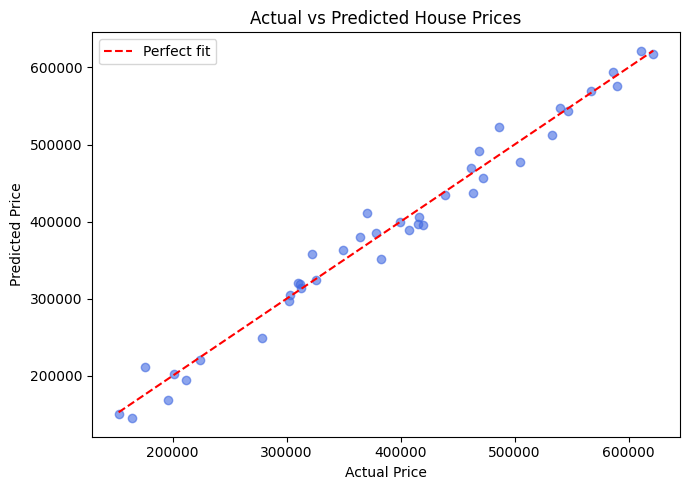

In [6]:
# ── 4. Train / Test Split & Model ─────────────────────────────────────────────
X = df_house[features]
y = df_house['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R²   : {r2:.4f}")

# Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue')
mn, mx = y_test.min(), y_test.max()
plt.plot([mn, mx], [mn, mx], 'r--', label='Perfect fit')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# ── 5. Predict a New House ────────────────────────────────────────────────────
new_house = pd.DataFrame([{
    'sqft': 2000,
    'bedrooms': 3,
    'bathrooms': 2,
    'age': 10,
    'neighborhood_enc': le.transform(['Suburbs'])[0]
}])

predicted_price = model_lr.predict(new_house)[0]
print(f"Predicted price for new house: ${predicted_price:,.2f}")

Predicted price for new house: $330,276.82


---
## Q2 – Email Spam Classification (Logistic Regression + Naive Bayes)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ── 1. Synthetic Email Dataset ────────────────────────────────────────────────
np.random.seed(0)
n = 500

# Feature engineering (numeric)
spam_flag   = np.random.choice([0, 1], size=n, p=[0.6, 0.4])
word_freq   = np.where(spam_flag, np.random.uniform(0.2, 1.0, n), np.random.uniform(0.0, 0.3, n))
email_len   = np.where(spam_flag, np.random.randint(200, 1000, n), np.random.randint(50, 400, n)).astype(float)
has_links   = np.where(spam_flag, np.random.choice([0,1], n, p=[0.2,0.8]),
                                   np.random.choice([0,1], n, p=[0.7,0.3])).astype(float)
sender_known= np.where(spam_flag, np.random.choice([0,1], n, p=[0.8,0.2]),
                                   np.random.choice([0,1], n, p=[0.2,0.8])).astype(float)

df_email = pd.DataFrame({
    'word_freq':    word_freq,
    'email_length': email_len,
    'has_links':    has_links,
    'sender_known': sender_known,
    'spam':         spam_flag
})

print("── Email dataset head ──")
print(df_email.head())
print("\nClass distribution:")
print(df_email['spam'].value_counts())

── Email dataset head ──
   word_freq  email_length  has_links  sender_known  spam
0   0.177864         284.0        0.0           1.0     0
1   0.498428         809.0        0.0           1.0     1
2   0.619976         255.0        1.0           0.0     1
3   0.212631          56.0        1.0           1.0     0
4   0.013193         124.0        0.0           1.0     0

Class distribution:
spam
0    304
1    196
Name: count, dtype: int64


In [9]:
# ── 2. Train / Test & Models ──────────────────────────────────────────────────
X_e = df_email.drop('spam', axis=1)
y_e = df_email['spam']

X_tr, X_te, y_tr, y_te = train_test_split(X_e, y_e, test_size=0.2, random_state=42)

lr_spam = LogisticRegression(max_iter=1000)
lr_spam.fit(X_tr, y_tr)
y_pred_lr = lr_spam.predict(X_te)

nb_spam = GaussianNB()
nb_spam.fit(X_tr, y_tr)
y_pred_nb = nb_spam.predict(X_te)

for name, preds in [('Logistic Regression', y_pred_lr), ('Naive Bayes', y_pred_nb)]:
    print(f"\n── {name} ──")
    print(f"Accuracy: {accuracy_score(y_te, preds):.4f}")
    print(classification_report(y_te, preds, target_names=['Not Spam', 'Spam']))


── Logistic Regression ──
Accuracy: 0.9900
              precision    recall  f1-score   support

    Not Spam       0.99      1.00      0.99        70
        Spam       1.00      0.97      0.98        30

    accuracy                           0.99       100
   macro avg       0.99      0.98      0.99       100
weighted avg       0.99      0.99      0.99       100


── Naive Bayes ──
Accuracy: 1.0000
              precision    recall  f1-score   support

    Not Spam       1.00      1.00      1.00        70
        Spam       1.00      1.00      1.00        30

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



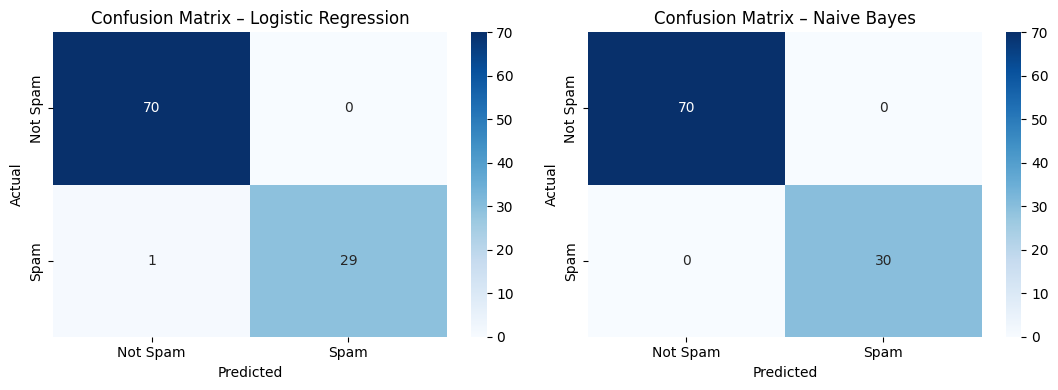

In [10]:
# ── 3. Confusion Matrix ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name, preds in zip(axes,
                            ['Logistic Regression', 'Naive Bayes'],
                            [y_pred_lr, y_pred_nb]):
    cm = confusion_matrix(y_te, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Spam','Spam'], yticklabels=['Not Spam','Spam'])
    ax.set_title(f'Confusion Matrix – {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [11]:
# ── 4. Classify New Incoming Email ────────────────────────────────────────────
new_email = pd.DataFrame([{
    'word_freq': 0.85,
    'email_length': 750,
    'has_links': 1,
    'sender_known': 0
}])

label_map = {0: 'Not Spam', 1: 'Spam'}
print("Logistic Regression prediction:", label_map[lr_spam.predict(new_email)[0]])
print("Naive Bayes prediction         :", label_map[nb_spam.predict(new_email)[0]])

Logistic Regression prediction: Spam
Naive Bayes prediction         : Spam


---
## Q3 – Customer Value Classification (SVM + Decision Tree)

In [12]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler

# ── 1. Synthetic Customer Dataset ─────────────────────────────────────────────
np.random.seed(7)
n = 300

spending       = np.random.uniform(100, 5000, n)
age            = np.random.randint(18, 70, n).astype(float)
num_visits     = np.random.randint(1, 50, n).astype(float)
purchase_freq  = np.random.uniform(0.5, 10, n)

# High-value rule: spending > 2500 OR (visits > 25 AND freq > 6)
label = ((spending > 2500) | ((num_visits > 25) & (purchase_freq > 6))).astype(int)

# Add outliers
spending[np.random.choice(n, 5)] = np.random.uniform(20000, 30000, 5)

df_cust = pd.DataFrame({
    'spending': spending,
    'age': age,
    'num_visits': num_visits,
    'purchase_freq': purchase_freq,
    'high_value': label
})

print("── Dataset head ──")
print(df_cust.head())
print("\nClass distribution:")
print(df_cust['high_value'].value_counts())

── Dataset head ──
      spending   age  num_visits  purchase_freq  high_value
0   473.910618  48.0        42.0       6.729167           1
1  3921.602082  68.0        21.0       7.875214           1
2  2248.205234  18.0         6.0       1.456462           0
3  3644.979371  52.0        36.0       0.825491           1
4  4892.148609  38.0        16.0       7.153058           1

Class distribution:
high_value
1    169
0    131
Name: count, dtype: int64


In [13]:
# ── 2. Handle Outliers (IQR cap) ──────────────────────────────────────────────
for col in ['spending', 'num_visits', 'purchase_freq']:
    Q1, Q3 = df_cust[col].quantile(0.25), df_cust[col].quantile(0.75)
    IQR = Q3 - Q1
    df_cust[col] = df_cust[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

print("Outliers capped. Spending max:", df_cust['spending'].max())

Outliers capped. Spending max: 7593.071475832598


In [14]:
# ── 3. Feature Scaling & Split ────────────────────────────────────────────────
feat_cols = ['spending', 'age', 'num_visits', 'purchase_freq']
X_c = df_cust[feat_cols]
y_c = df_cust['high_value']

scaler_c = StandardScaler()
X_scaled_c = scaler_c.fit_transform(X_c)

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_scaled_c, y_c, test_size=0.2, random_state=42)

# ── 4a. SVM (separating hyperplane) ──────────────────────────────────────────
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(Xc_tr, yc_tr)
y_svm = svm_model.predict(Xc_te)

print("── SVM ──")
print(f"Accuracy: {accuracy_score(yc_te, y_svm):.4f}")
print(classification_report(yc_te, y_svm, target_names=['Low-Value','High-Value']))

── SVM ──
Accuracy: 0.9167
              precision    recall  f1-score   support

   Low-Value       0.88      0.92      0.90        24
  High-Value       0.94      0.92      0.93        36

    accuracy                           0.92        60
   macro avg       0.91      0.92      0.91        60
weighted avg       0.92      0.92      0.92        60



── Decision Tree ──
Accuracy: 0.9833
              precision    recall  f1-score   support

   Low-Value       1.00      0.96      0.98        24
  High-Value       0.97      1.00      0.99        36

    accuracy                           0.98        60
   macro avg       0.99      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



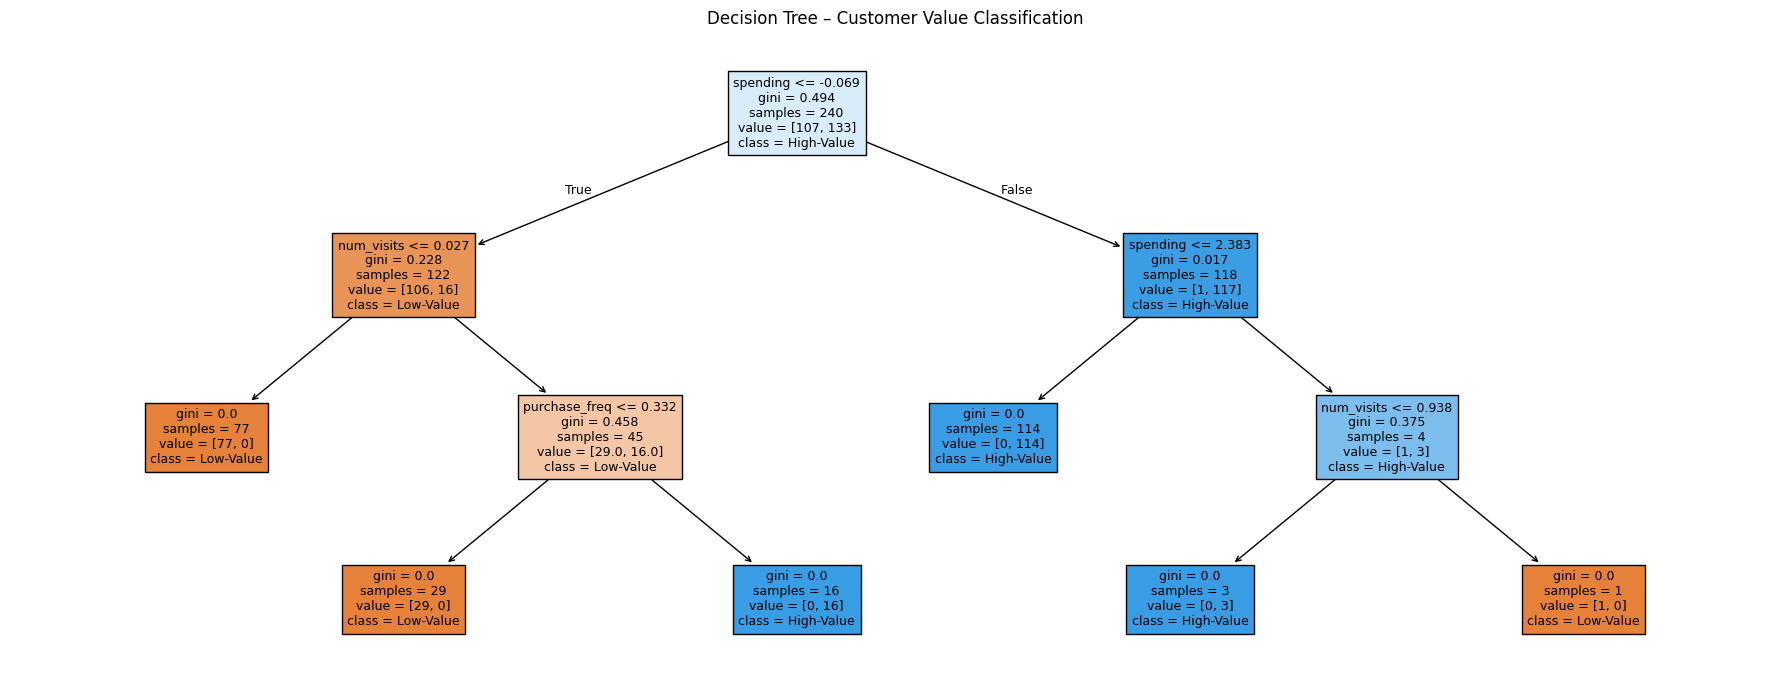

In [15]:
# ── 4b. Decision Tree (rules) ─────────────────────────────────────────────────
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(Xc_tr, yc_tr)
y_dt = dt_model.predict(Xc_te)

print("── Decision Tree ──")
print(f"Accuracy: {accuracy_score(yc_te, y_dt):.4f}")
print(classification_report(yc_te, y_dt, target_names=['Low-Value','High-Value']))

plt.figure(figsize=(18, 7))
plot_tree(dt_model, feature_names=feat_cols,
          class_names=['Low-Value','High-Value'],
          filled=True, fontsize=9)
plt.title('Decision Tree – Customer Value Classification')
plt.tight_layout()
plt.show()

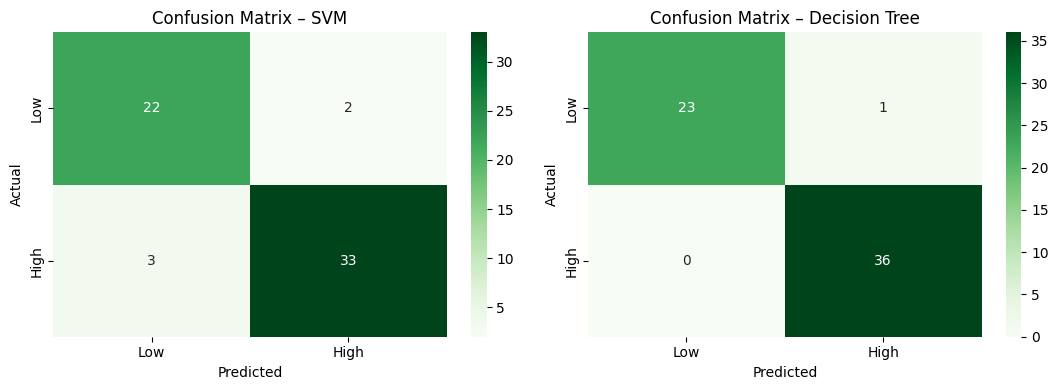

In [16]:
# ── 5. Confusion Matrices ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name, preds in zip(axes, ['SVM', 'Decision Tree'], [y_svm, y_dt]):
    cm = confusion_matrix(yc_te, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
                xticklabels=['Low','High'], yticklabels=['Low','High'])
    ax.set_title(f'Confusion Matrix – {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

---
## Q4 – K-Means on Mall Customers (All Features, With vs Without Scaling)

In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Synthetic Mall Customers Dataset ─────────────────────────────────────────
np.random.seed(42)
n = 200
df_mall = pd.DataFrame({
    'CustomerID':    range(1, n+1),
    'Gender':        np.random.choice(['Male','Female'], n),
    'Age':           np.random.randint(18, 70, n),
    'Annual_Income': np.random.randint(15, 140, n),   # k$
    'Spending_Score': np.random.randint(1, 101, n)
})

print("── Mall Customers head ──")
print(df_mall.head())

── Mall Customers head ──
   CustomerID  Gender  Age  Annual_Income  Spending_Score
0           1    Male   49             68              86
1           2  Female   56             22              57
2           3    Male   66             41              29
3           4    Male   69             41              78
4           5    Male   49            112              92


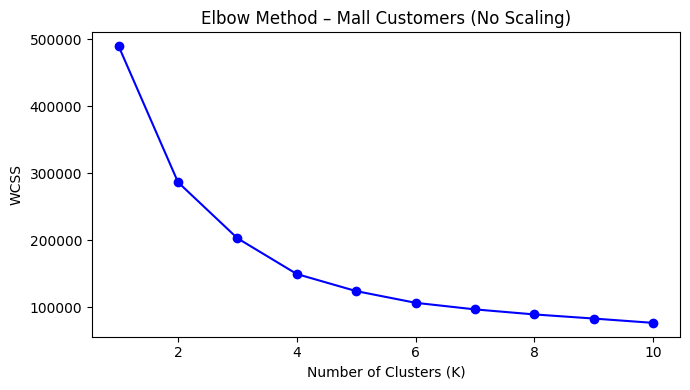

In [18]:
# ── Encode Gender & drop CustomerID ───────────────────────────────────────────
df_mall['Gender_enc'] = LabelEncoder().fit_transform(df_mall['Gender'])
features_mall = ['Gender_enc', 'Age', 'Annual_Income', 'Spending_Score']
X_mall = df_mall[features_mall].values

# ── Elbow Method ─────────────────────────────────────────────────────────────
wcss = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_mall)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, wcss, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method – Mall Customers (No Scaling)')
plt.tight_layout()
plt.show()

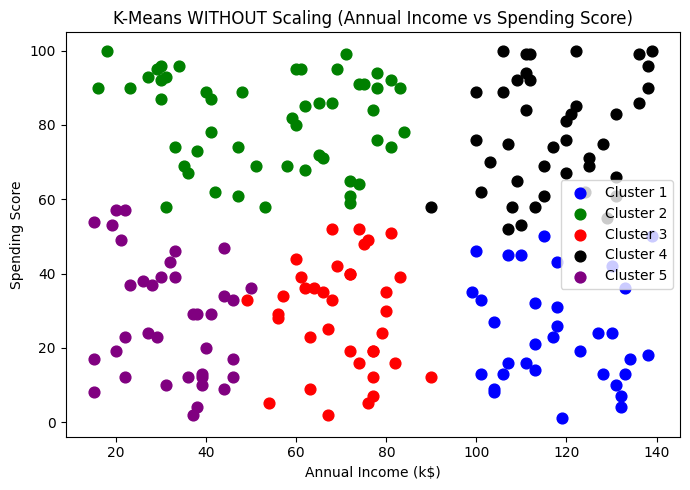

In [19]:
# ── Clustering WITHOUT Scaling ────────────────────────────────────────────────
K_OPT = 5
km_no_scale = KMeans(n_clusters=K_OPT, init='k-means++', random_state=42, n_init=10)
df_mall['Cluster_NoScale'] = km_no_scale.fit_predict(X_mall)

plt.figure(figsize=(7, 5))
colors = ['blue','green','red','black','purple']
for i in range(K_OPT):
    mask = df_mall['Cluster_NoScale'] == i
    plt.scatter(df_mall.loc[mask,'Annual_Income'],
                df_mall.loc[mask,'Spending_Score'],
                s=60, c=colors[i], label=f'Cluster {i+1}')
plt.title('K-Means WITHOUT Scaling (Annual Income vs Spending Score)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend()
plt.tight_layout()
plt.show()

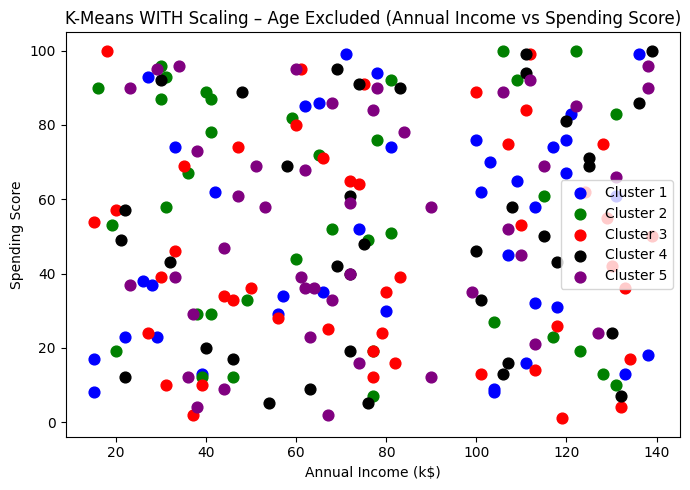


── Cluster Sizes (No Scale) ──
Cluster_NoScale
0    35
1    51
2    36
3    41
4    37
Name: count, dtype: int64

── Cluster Sizes (Scaled) ──
Cluster_Scaled
0    39
1    37
2    45
3    36
4    43
Name: count, dtype: int64

Insight: Without scaling, Annual Income (15–140) dominates distance
calculations and drowns out Gender_enc (0/1). After scaling, clusters
are more balanced across all features, producing more semantically
meaningful customer segments.


In [20]:
# ── Clustering WITH Scaling (all features except Age) ────────────────────────
# Age is excluded from scaling as per task instructions
cols_to_scale = ['Gender_enc', 'Annual_Income', 'Spending_Score']
X_scaled_mall  = X_mall.copy().astype(float)
sc_mall        = StandardScaler()
idx_scale      = [features_mall.index(c) for c in cols_to_scale]
X_scaled_mall[:, idx_scale] = sc_mall.fit_transform(X_mall[:, idx_scale])

km_scaled = KMeans(n_clusters=K_OPT, init='k-means++', random_state=42, n_init=10)
df_mall['Cluster_Scaled'] = km_scaled.fit_predict(X_scaled_mall)

plt.figure(figsize=(7, 5))
for i in range(K_OPT):
    mask = df_mall['Cluster_Scaled'] == i
    plt.scatter(df_mall.loc[mask,'Annual_Income'],
                df_mall.loc[mask,'Spending_Score'],
                s=60, c=colors[i], label=f'Cluster {i+1}')
plt.title('K-Means WITH Scaling – Age Excluded (Annual Income vs Spending Score)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend()
plt.tight_layout()
plt.show()

print()
print("── Cluster Sizes (No Scale) ──")
print(df_mall['Cluster_NoScale'].value_counts().sort_index())
print("\n── Cluster Sizes (Scaled) ──")
print(df_mall['Cluster_Scaled'].value_counts().sort_index())
print()
print("""Insight: Without scaling, Annual Income (15–140) dominates distance
calculations and drowns out Gender_enc (0/1). After scaling, clusters
are more balanced across all features, producing more semantically
meaningful customer segments.""")

---
## Q5 – K-Means on Vehicle Fleet Data (With vs Without Scaling)

In [21]:
# ── Dataset (as given in task) ────────────────────────────────────────────────
data_veh = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage':           [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency':   [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost':  [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type':      ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}
df_veh = pd.DataFrame(data_veh)

# Encode vehicle_type
le_veh = LabelEncoder()
df_veh['vehicle_type_enc'] = le_veh.fit_transform(df_veh['vehicle_type'])
print("Vehicle type encoding:", dict(zip(le_veh.classes_, le_veh.transform(le_veh.classes_))))

feat_veh = ['vehicle_serial_no', 'mileage', 'fuel_efficiency', 'maintenance_cost', 'vehicle_type_enc']
X_veh = df_veh[feat_veh].values

print("\n── Vehicle dataset ──")
print(df_veh)

Vehicle type encoding: {'Hatchback': np.int64(0), 'SUV': np.int64(1), 'Sedan': np.int64(2), 'Truck': np.int64(3)}

── Vehicle dataset ──
   vehicle_serial_no  mileage  fuel_efficiency  maintenance_cost vehicle_type  \
0                  5   150000               15              5000          SUV   
1                  3   120000               18              4000        Sedan   
2                  8   250000               10              7000        Truck   
3                  2    80000               22              2000    Hatchback   
4                  4   100000               20              3000        Sedan   
5                  7   220000               12              6500        Truck   
6                  6   180000               16              5500          SUV   
7                 10   300000                8              8000        Truck   
8                  1    75000               24              1500    Hatchback   
9                  9   280000                9       

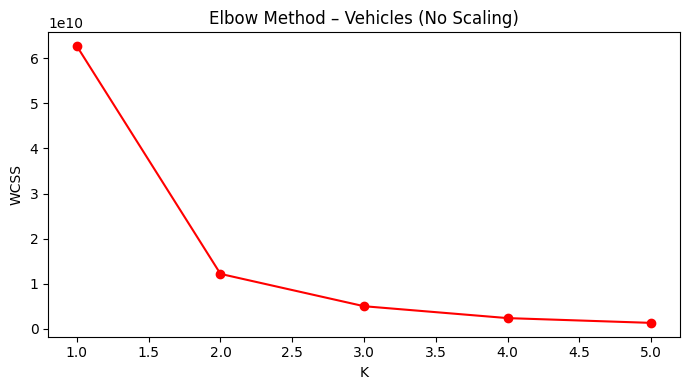

In [22]:
# ── Elbow (no scaling) ────────────────────────────────────────────────────────
wcss_veh = []
for k in range(1, 6):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_veh)
    wcss_veh.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 6), wcss_veh, 'ro-')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Method – Vehicles (No Scaling)')
plt.tight_layout()
plt.show()

In [23]:
# ── K-Means WITHOUT Scaling ───────────────────────────────────────────────────
K_VEH = 3
km_veh_ns = KMeans(n_clusters=K_VEH, init='k-means++', random_state=42, n_init=10)
df_veh['Cluster_NoScale'] = km_veh_ns.fit_predict(X_veh)

# ── K-Means WITH Scaling (vehicle_type excluded) ──────────────────────────────
cols_scale_veh = ['vehicle_serial_no', 'mileage', 'fuel_efficiency', 'maintenance_cost']
X_veh_scaled   = X_veh.copy().astype(float)
sc_veh         = StandardScaler()
idx_sv = [feat_veh.index(c) for c in cols_scale_veh]
X_veh_scaled[:, idx_sv] = sc_veh.fit_transform(X_veh[:, idx_sv])

km_veh_sc = KMeans(n_clusters=K_VEH, init='k-means++', random_state=42, n_init=10)
df_veh['Cluster_Scaled'] = km_veh_sc.fit_predict(X_veh_scaled)

print("── Results ──")
print(df_veh[['vehicle_serial_no','vehicle_type','mileage','fuel_efficiency',
               'maintenance_cost','Cluster_NoScale','Cluster_Scaled']])

── Results ──
   vehicle_serial_no vehicle_type  mileage  fuel_efficiency  maintenance_cost  \
0                  5          SUV   150000               15              5000   
1                  3        Sedan   120000               18              4000   
2                  8        Truck   250000               10              7000   
3                  2    Hatchback    80000               22              2000   
4                  4        Sedan   100000               20              3000   
5                  7        Truck   220000               12              6500   
6                  6          SUV   180000               16              5500   
7                 10        Truck   300000                8              8000   
8                  1    Hatchback    75000               24              1500   
9                  9          SUV   280000                9              7500   

   Cluster_NoScale  Cluster_Scaled  
0                2               2  
1                0  

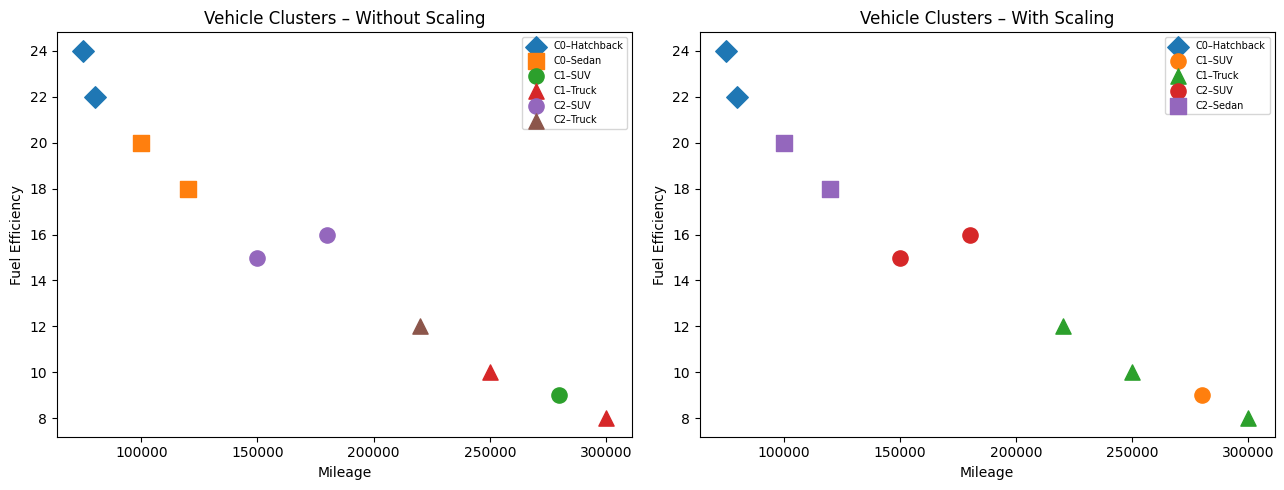


Insight: Without scaling, mileage (75k–300k) completely dominates
the distance metric, causing clustering purely on mileage ranges.
With scaling, fuel efficiency and maintenance cost contribute equally,
revealing more meaningful fleet segments (e.g., high-mileage–low-
efficiency trucks vs. low-mileage–high-efficiency hatchbacks).


In [24]:
# ── Visualization: Mileage vs Fuel Efficiency ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
vtype_markers = {'SUV':'o', 'Sedan':'s', 'Truck':'^', 'Hatchback':'D'}

for ax, col, title in zip(axes,
                           ['Cluster_NoScale','Cluster_Scaled'],
                           ['Without Scaling','With Scaling']):
    for c in range(K_VEH):
        sub = df_veh[df_veh[col] == c]
        for vt, grp in sub.groupby('vehicle_type'):
            ax.scatter(grp['mileage'], grp['fuel_efficiency'],
                       marker=vtype_markers[vt], s=120,
                       label=f'C{c}–{vt}')
    ax.set_title(f'Vehicle Clusters – {title}')
    ax.set_xlabel('Mileage')
    ax.set_ylabel('Fuel Efficiency')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print()
print("""Insight: Without scaling, mileage (75k–300k) completely dominates
the distance metric, causing clustering purely on mileage ranges.
With scaling, fuel efficiency and maintenance cost contribute equally,
revealing more meaningful fleet segments (e.g., high-mileage–low-
efficiency trucks vs. low-mileage–high-efficiency hatchbacks).""")

---
## Q6 – K-Means on Student Academic Data (Elbow Method + Visualization)

In [25]:
# ── Synthetic Student Dataset ─────────────────────────────────────────────────
np.random.seed(99)
n_stu = 120

# Three natural groups: struggling / average / high-performing
gpa_s   = np.concatenate([np.random.uniform(1.5, 2.5, 40),
                           np.random.uniform(2.5, 3.3, 40),
                           np.random.uniform(3.3, 4.0, 40)])
hours_s = np.concatenate([np.random.uniform(2,  8,  40),
                           np.random.uniform(8,  18, 40),
                           np.random.uniform(18, 30, 40)])
attend_s= np.concatenate([np.random.uniform(40, 70, 40),
                           np.random.uniform(65, 85, 40),
                           np.random.uniform(80, 100,40)])

df_stu = pd.DataFrame({
    'student_id':     range(1, n_stu+1),
    'GPA':            np.round(gpa_s, 2),
    'study_hours':    np.round(hours_s, 1),
    'attendance_rate': np.round(attend_s, 1)
})

print("── Student Dataset ──")
print(df_stu.head(10))
print(f"\nShape: {df_stu.shape}")

── Student Dataset ──
   student_id   GPA  study_hours  attendance_rate
0           1  2.17          7.1             65.4
1           2  1.99          6.0             59.3
2           3  2.33          5.1             56.0
3           4  1.53          6.6             68.9
4           5  2.31          6.7             48.8
5           6  2.07          5.3             49.2
6           7  1.80          6.1             43.0
7           8  1.55          3.5             52.1
8           9  2.49          6.2             55.6
9          10  1.51          4.4             43.1

Shape: (120, 4)


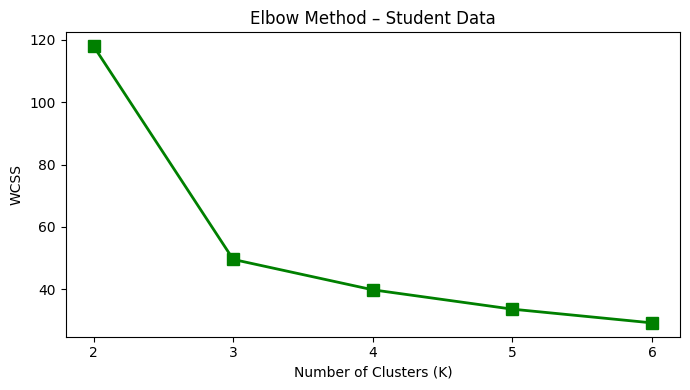

WCSS values: [118.01, 49.56, 39.8, 33.59, 29.19]


In [26]:
# ── Feature Scaling ───────────────────────────────────────────────────────────
feat_stu = ['GPA', 'study_hours', 'attendance_rate']
X_stu    = df_stu[feat_stu].values

sc_stu    = StandardScaler()
X_stu_sc  = sc_stu.fit_transform(X_stu)

# ── Elbow Method (K = 2 to 6) ─────────────────────────────────────────────────
wcss_stu = []
K_range_stu = range(2, 7)
for k in K_range_stu:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_stu_sc)
    wcss_stu.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range_stu), wcss_stu, 'gs-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method – Student Data')
plt.xticks(list(K_range_stu))
plt.tight_layout()
plt.show()

print("WCSS values:", [round(w, 2) for w in wcss_stu])

In [27]:
# ── Apply K-Means with Optimal K = 3 ─────────────────────────────────────────
K_STU = 3   # clear elbow at K=3
km_stu = KMeans(n_clusters=K_STU, init='k-means++', random_state=42, n_init=10)
df_stu['Cluster'] = km_stu.fit_predict(X_stu_sc)

# Label clusters by mean GPA
cluster_labels = (
    df_stu.groupby('Cluster')['GPA']
    .mean()
    .sort_values()
    .reset_index()
)
label_map_stu = {
    cluster_labels.iloc[0]['Cluster']: 'Struggling',
    cluster_labels.iloc[1]['Cluster']: 'Average',
    cluster_labels.iloc[2]['Cluster']: 'High-Performing'
}
df_stu['Group'] = df_stu['Cluster'].map(label_map_stu)

print("── Cluster Summary ──")
print(df_stu.groupby('Group')[feat_stu].mean().round(2))

── Cluster Summary ──
                  GPA  study_hours  attendance_rate
Group                                              
Average          2.93        12.70            75.85
High-Performing  3.64        24.47            90.38
Struggling       1.97         5.37            54.70


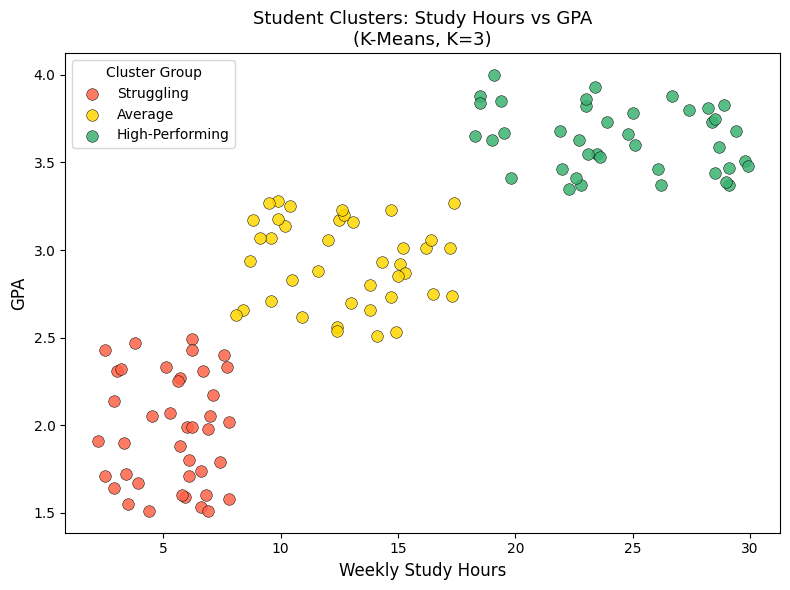

In [28]:
# ── Scatter Plot: Study Hours vs GPA ──────────────────────────────────────────
palette = {'Struggling': 'tomato', 'Average': 'gold', 'High-Performing': 'mediumseagreen'}

plt.figure(figsize=(8, 6))
for grp, color in palette.items():
    sub = df_stu[df_stu['Group'] == grp]
    plt.scatter(sub['study_hours'], sub['GPA'],
                c=color, s=70, alpha=0.85, edgecolors='k', linewidths=0.4,
                label=grp)

plt.xlabel('Weekly Study Hours', fontsize=12)
plt.ylabel('GPA', fontsize=12)
plt.title('Student Clusters: Study Hours vs GPA\n(K-Means, K=3)', fontsize=13)
plt.legend(title='Cluster Group', fontsize=10)
plt.tight_layout()
plt.show()

In [29]:
# ── Final Dataset: Student IDs + Cluster Labels ───────────────────────────────
print("── Final Student Dataset with Cluster Assignments ──")
print(df_stu[['student_id','GPA','study_hours','attendance_rate','Group']].to_string(index=False))

── Final Student Dataset with Cluster Assignments ──
 student_id  GPA  study_hours  attendance_rate           Group
          1 2.17          7.1             65.4      Struggling
          2 1.99          6.0             59.3      Struggling
          3 2.33          5.1             56.0      Struggling
          4 1.53          6.6             68.9      Struggling
          5 2.31          6.7             48.8      Struggling
          6 2.07          5.3             49.2      Struggling
          7 1.80          6.1             43.0      Struggling
          8 1.55          3.5             52.1      Struggling
          9 2.49          6.2             55.6      Struggling
         10 1.51          4.4             43.1      Struggling
         11 2.27          5.7             50.0      Struggling
         12 2.25          5.6             52.7      Struggling
         13 1.88          5.7             69.7      Struggling
         14 1.99          6.2             69.3      Struggling
  